In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(
    r"C:\Users\adity\Desktop\OnlineRetail_Cleaned_Sales.csv",
    low_memory=False
)

df["InvoiceDate"] = pd.to_datetime(
    df["InvoiceDate"],
    format="%d-%m-%Y %H:%M"
)

print("Shape:", df.shape)
df.head()

Shape: (529083, 9)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


In [2]:
print(df["InvoiceDate"].dtype)
print("Start:", df["InvoiceDate"].min())
print("End:", df["InvoiceDate"].max())

datetime64[ns]
Start: 2010-12-01 08:26:00
End: 2011-12-09 12:50:00


In [3]:
df.groupby("Description")["Revenue"].sum()

Description
 4 PURPLE FLOCK DINNER CANDLES     290.80
 50'S CHRISTMAS GIFT BAG LARGE    2343.63
 DOLLY GIRL BEAKER                2891.25
 I LOVE LONDON MINI BACKPACK      1628.17
 I LOVE LONDON MINI RUCKSACK         4.15
                                   ...   
wrongly coded 20713                  0.00
wrongly coded 23343                  0.00
wrongly marked                       0.00
wrongly marked 23343                 0.00
wrongly sold (22719) barcode         0.00
Name: Revenue, Length: 4069, dtype: float64

In [4]:
df.groupby("Description")["Quantity"].sum()

Description
 4 PURPLE FLOCK DINNER CANDLES     144
 50'S CHRISTMAS GIFT BAG LARGE    1915
 DOLLY GIRL BEAKER                2455
 I LOVE LONDON MINI BACKPACK       389
 I LOVE LONDON MINI RUCKSACK         1
                                  ... 
wrongly coded 20713                800
wrongly coded 23343               1000
wrongly marked                      48
wrongly marked 23343               200
wrongly sold (22719) barcode       170
Name: Quantity, Length: 4069, dtype: int64

In [5]:
print("Dataset Shape:", df.shape)

print("\n--- Data Types ---")
print(df.dtypes)

print("\n--- Unique Values ---")
print("Invoices:", df["InvoiceNo"].nunique())
print("Customers:", df["CustomerID"].nunique())
print("Products:", df["StockCode"].nunique())
print("Countries:", df["Country"].nunique())

print("\n--- Date Range ---")
print("Start:", df["InvoiceDate"].min())
print("End:", df["InvoiceDate"].max())

print("\n--- Missing Values ---")
print(df.isnull().sum())

print("\n--- Numerical Summary ---")
display(df[["Quantity", "UnitPrice", "Revenue"]].describe())

Dataset Shape: (529083, 9)

--- Data Types ---
InvoiceNo               int64
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[ns]
UnitPrice             float64
CustomerID             object
Country                object
Revenue               float64
dtype: object

--- Unique Values ---
Invoices: 20556
Customers: 4337
Products: 3931
Countries: 38

--- Date Range ---
Start: 2010-12-01 08:26:00
End: 2011-12-09 12:50:00

--- Missing Values ---
InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
Revenue        0
dtype: int64

--- Numerical Summary ---


,Quantity,UnitPrice,Revenue
count,529083.000000,529083.000000,529083.000000
mean,10.670229,3.271957,19.428029
std,157.099233,4.446968,268.271196
min,1.000000,0.000000,0.000000
25%,1.000000,1.250000,3.750000
50%,3.000000,2.080000,9.900000
75%,11.000000,4.130000,17.400000
max,80995.000000,649.500000,168469.600000


In [6]:
df = df.iloc[:, :9].copy()

In [7]:

print(df.shape)
print(df.columns.tolist())

(529083, 9)
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country', 'Revenue']


In [8]:
# Core Sales KPIs

total_revenue = df["Revenue"].sum()
total_quantity = df["Quantity"].sum()
total_orders = df["InvoiceNo"].nunique()
total_customers = df["CustomerID"].nunique()
total_products = df["StockCode"].nunique()

average_order_value = total_revenue / total_orders

print(f"Total Revenue: £{total_revenue:,.2f}")
print(f"Total Quantity Sold: {total_quantity:,}")
print(f"Total Orders: {total_orders:,}")
print(f"Total Customers: {total_customers:,}")
print(f"Total Products: {total_products:,}")
print(f"Average Order Value: £{average_order_value:,.2f}")

Total Revenue: £10,279,039.89
Total Quantity Sold: 5,645,437
Total Orders: 20,556
Total Customers: 4,337
Total Products: 3,931
Average Order Value: £500.05


In [9]:
monthly_sales = (
    df.set_index("InvoiceDate")
      .resample("MS")
      .agg(
          Revenue=("Revenue", "sum"),
          Orders=("InvoiceNo", "nunique"),
          Quantity=("Quantity", "sum")
      )
      .reset_index()
)

monthly_sales

,InvoiceDate,Revenue,Orders,Quantity
0,2010-12-01,778623.36,1624,361839
1,2011-01-01,672207.41,1115,396363
2,2011-02-01,509151.42,1121,286391
3,2011-03-01,691890.92,1517,383511
4,2011-04-01,516718.21,1308,311885
5,2011-05-01,741690.55,1720,398280
6,2011-06-01,739426.88,1569,393967
7,2011-07-01,689873.19,1517,407121
8,2011-08-01,725985.42,1387,424696
9,2011-09-01,1031423.78,1878,573811


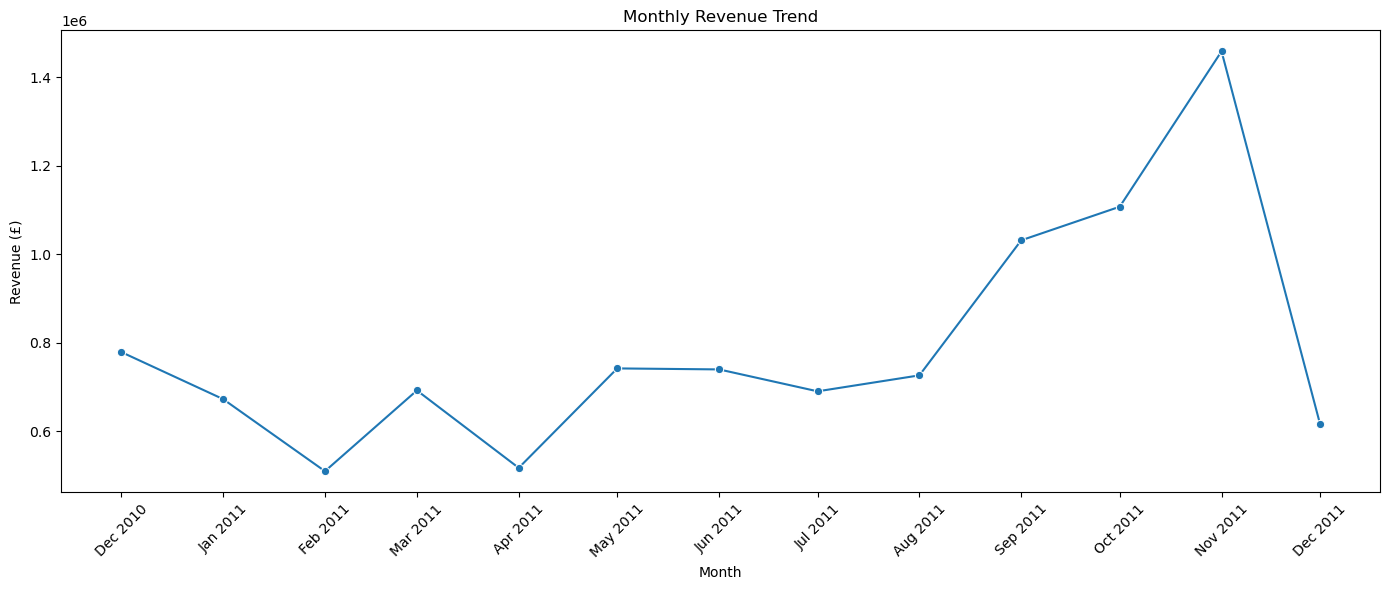

In [10]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_sales,
    x="InvoiceDate",
    y="Revenue",
    marker="o"
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue (£)")

plt.xticks(
    monthly_sales["InvoiceDate"],
    monthly_sales["InvoiceDate"].dt.strftime("%b %Y"),
    rotation=45
)

plt.tight_layout()
plt.show()

In [11]:
monthly_sales["Average_Order_Value"] = (
    monthly_sales["Revenue"] / monthly_sales["Orders"]
)

monthly_sales

,InvoiceDate,Revenue,Orders,Quantity,Average_Order_Value
0,2010-12-01,778623.36,1624,361839,479.447882
1,2011-01-01,672207.41,1115,396363,602.876601
2,2011-02-01,509151.42,1121,286391,454.193952
3,2011-03-01,691890.92,1517,383511,456.091575
4,2011-04-01,516718.21,1308,311885,395.044503
5,2011-05-01,741690.55,1720,398280,431.215436
6,2011-06-01,739426.88,1569,393967,471.272709
7,2011-07-01,689873.19,1517,407121,454.761496
8,2011-08-01,725985.42,1387,424696,523.421355
9,2011-09-01,1031423.78,1878,573811,549.213940


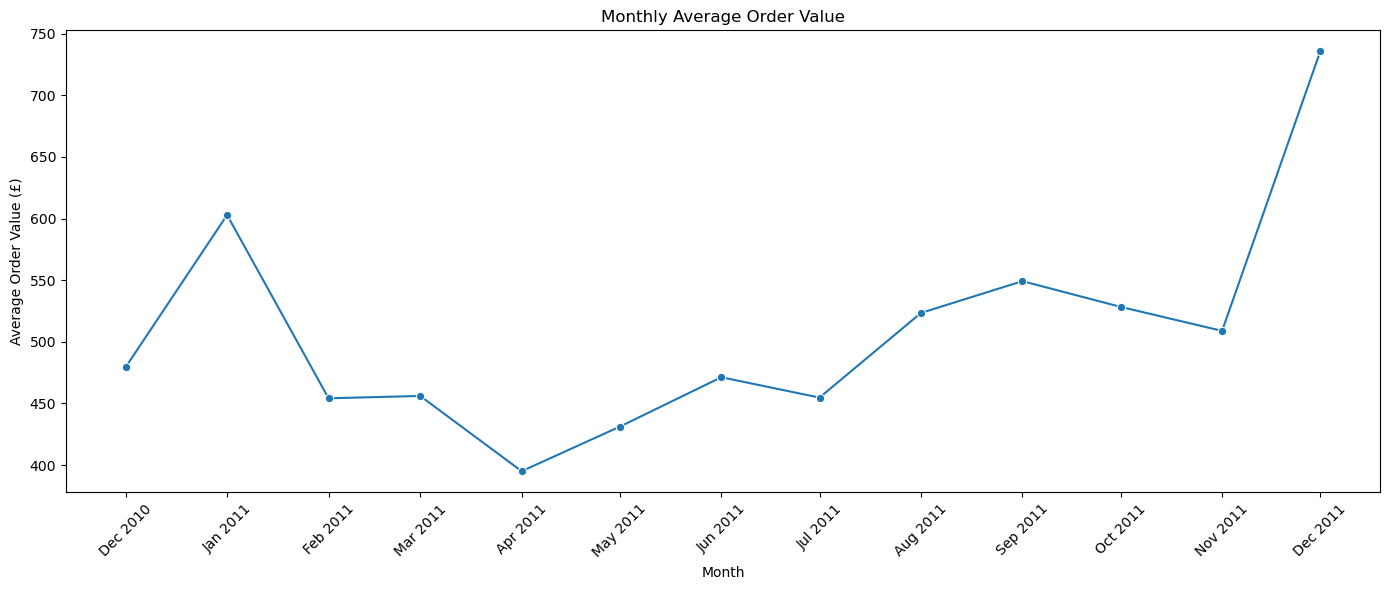

In [12]:
plt.figure(figsize=(14, 6))

sns.lineplot(
    data=monthly_sales,
    x="InvoiceDate",
    y="Average_Order_Value",
    marker="o"
)

plt.title("Monthly Average Order Value")
plt.xlabel("Month")
plt.ylabel("Average Order Value (£)")

plt.xticks(
    monthly_sales["InvoiceDate"],
    monthly_sales["InvoiceDate"].dt.strftime("%b %Y"),
    rotation=45
)

plt.tight_layout()
plt.show()

In [13]:
# Top 10 Products by Revenue

top_products_revenue = (
    df.groupby("Description")
      .agg(
          Total_Revenue=("Revenue", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Total_Orders=("InvoiceNo", "nunique")
      )
      .sort_values("Total_Revenue", ascending=False)
      .head(10)
      .reset_index()
)

top_products_revenue

,Description,Total_Revenue,Total_Quantity,Total_Orders
0,REGENCY CAKESTAND 3 TIER,174484.74,13890,1989
1,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1
2,WHITE HANGING HEART T-LIGHT HOLDER,106292.77,37895,2260
3,PARTY BUNTING,99504.33,18299,1686
4,JUMBO BAG RED RETROSPOT,94340.05,48478,2092
5,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247
6,RABBIT NIGHT LIGHT,66964.99,30788,994
7,PAPER CHAIN KIT 50'S CHRISTMAS,64952.29,19355,1160
8,ASSORTED COLOUR BIRD ORNAMENT,59094.93,36461,1455
9,CHILLI LIGHTS,54117.76,10309,663


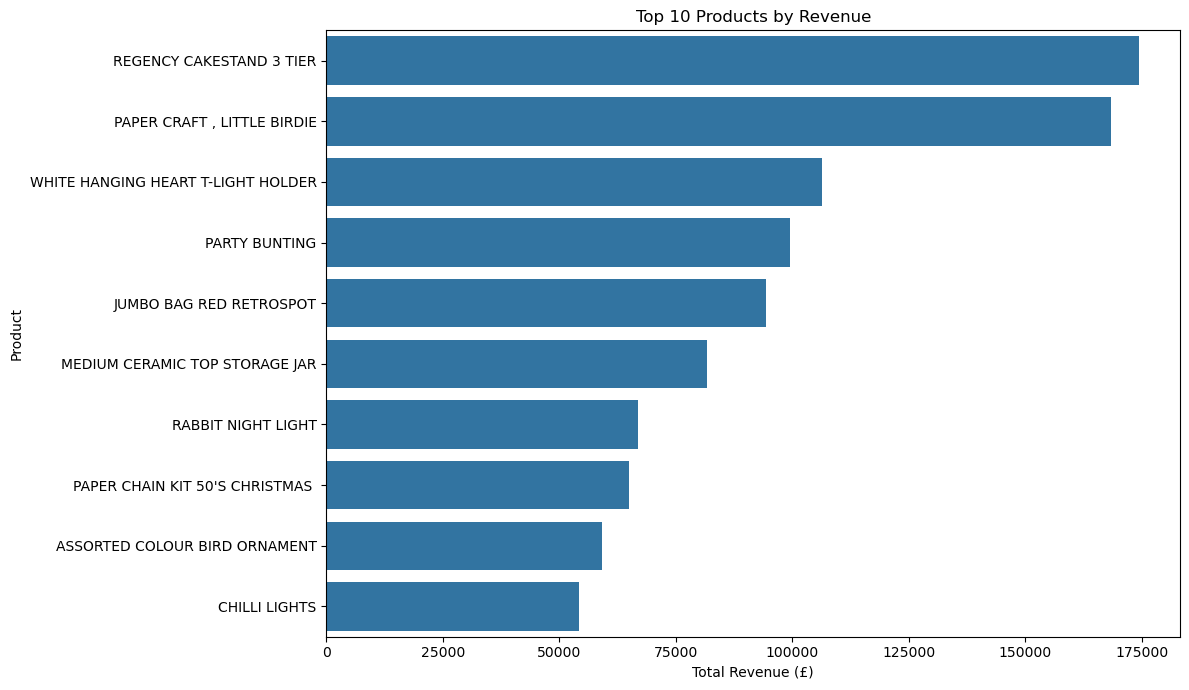

In [14]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_products_revenue,
    x="Total_Revenue",
    y="Description"
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Total Revenue (£)")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [15]:
product_analysis = (
    df.groupby("Description")
      .agg(
          Total_Revenue=("Revenue", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Total_Orders=("InvoiceNo", "nunique")
      )
      .reset_index()
)

product_analysis["Revenue_Per_Order"] = (
    product_analysis["Total_Revenue"] /
    product_analysis["Total_Orders"]
)

product_analysis["Quantity_Per_Order"] = (
    product_analysis["Total_Quantity"] /
    product_analysis["Total_Orders"]
)

In [16]:
product_analysis = (
    df.groupby("Description")
      .agg(
          Total_Revenue=("Revenue", "sum"),
          Total_Quantity=("Quantity", "sum"),
          Total_Orders=("InvoiceNo", "nunique")
      )
      .reset_index()
)

product_analysis["Revenue_Per_Order"] = (
    product_analysis["Total_Revenue"] /
    product_analysis["Total_Orders"]
)

product_analysis["Quantity_Per_Order"] = (
    product_analysis["Total_Quantity"] /
    product_analysis["Total_Orders"]
)

product_analysis.sort_values(
    "Total_Revenue",
    ascending=False
).head(10)

,Description,Total_Revenue,Total_Quantity,Total_Orders,Revenue_Per_Order,Quantity_Per_Order
2859,REGENCY CAKESTAND 3 TIER,174484.74,13890,1989,87.724857,6.983409
2394,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,168469.600000,80995.000000
3852,WHITE HANGING HEART T-LIGHT HOLDER,106292.77,37895,2260,47.032199,16.767699
2420,PARTY BUNTING,99504.33,18299,1686,59.017989,10.853499
1822,JUMBO BAG RED RETROSPOT,94340.05,48478,2092,45.095626,23.173040
2060,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247,330.772955,315.923077
2747,RABBIT NIGHT LIGHT,66964.99,30788,994,67.369205,30.973843
2388,PAPER CHAIN KIT 50'S CHRISTMAS,64952.29,19355,1160,55.993353,16.685345
228,ASSORTED COLOUR BIRD ORNAMENT,59094.93,36461,1455,40.615072,25.059107
750,CHILLI LIGHTS,54117.76,10309,663,81.625581,15.549020


In [17]:
top_products_quantity = (
    product_analysis
    .sort_values("Total_Quantity", ascending=False)
    .head(10)
)

top_products_quantity

,Description,Total_Revenue,Total_Quantity,Total_Orders,Revenue_Per_Order,Quantity_Per_Order
2394,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,168469.600000,80995.000000
2060,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247,330.772955,315.923077
3942,WORLD WAR 2 GLIDERS ASSTD DESIGNS,13841.85,55047,535,25.872617,102.891589
1822,JUMBO BAG RED RETROSPOT,94340.05,48478,2092,45.095626,23.173040
3852,WHITE HANGING HEART T-LIGHT HOLDER,106292.77,37895,2260,47.032199,16.767699
2688,POPCORN HOLDER,34298.87,36761,803,42.713412,45.779577
228,ASSORTED COLOUR BIRD ORNAMENT,59094.93,36461,1455,40.615072,25.059107
2345,PACK OF 72 RETROSPOT CAKE CASES,21259.10,36419,1320,16.105379,27.590152
2747,RABBIT NIGHT LIGHT,66964.99,30788,994,67.369205,30.973843
3677,Unknown_Item,0.00,28197,587,0.000000,48.035775


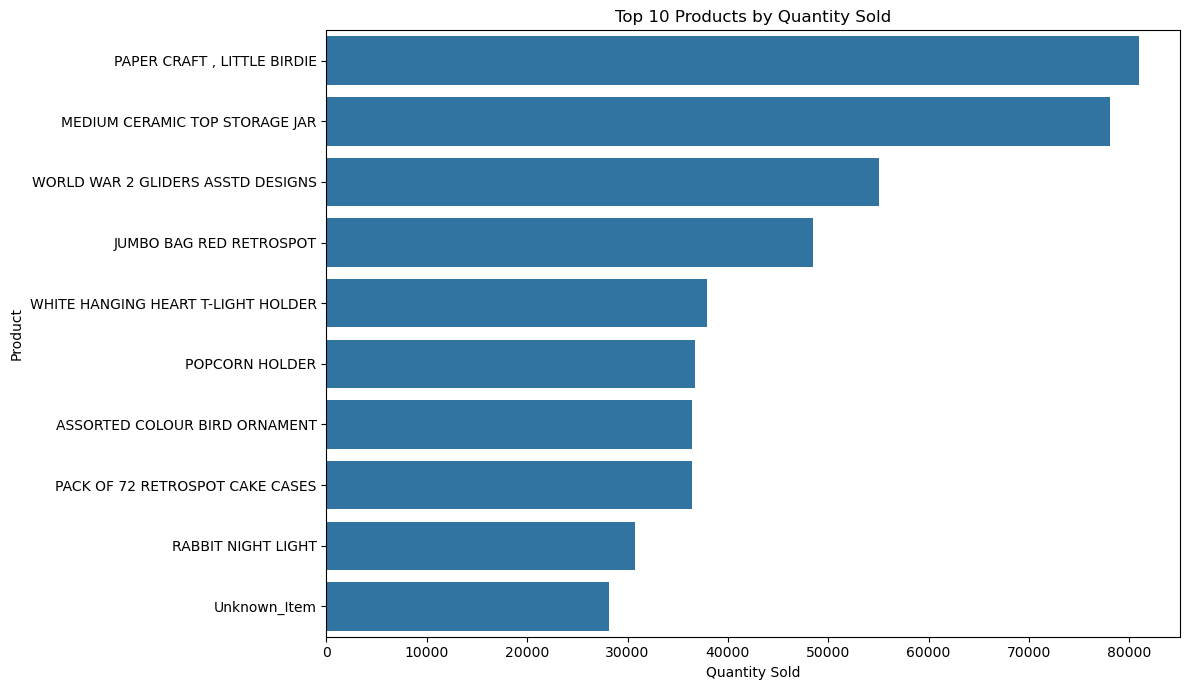

In [18]:
plt.figure(figsize=(12, 7))

sns.barplot(
    data=top_products_quantity,
    x="Total_Quantity",
    y="Description"
)

plt.title("Top 10 Products by Quantity Sold")
plt.xlabel("Quantity Sold")
plt.ylabel("Product")

plt.tight_layout()
plt.show()

In [19]:
product_analysis.sort_values(
    "Revenue_Per_Order",
    ascending=False
).head(10)

,Description,Total_Revenue,Total_Quantity,Total_Orders,Revenue_Per_Order,Quantity_Per_Order
2394,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,168469.600000,80995.000000
2470,PICNIC BASKET WICKER 60 PIECES,39619.50,61,2,19809.750000,30.500000
3569,TEA TIME TEA TOWELS,6045.00,2600,2,3022.500000,1300.000000
2150,MISELTOE HEART WREATH CREAM,996.00,240,1,996.000000,240.000000
3275,SET/5 RED SPOTTY LID GLASS BOWLS,734.40,288,1,734.400000,288.000000
3822,WEEKEND BAG VINTAGE ROSE PAISLEY,527.85,69,1,527.850000,69.000000
1596,HALL CABINET WITH 3 DRAWERS,2603.53,76,5,520.706000,15.200000
3676,UTILTY CABINET WITH HOOKS,2610.29,131,6,435.048333,21.833333
2703,POTTING SHED CANDLE CITRONELLA,1268.19,405,3,422.730000,135.000000
2060,MEDIUM CERAMIC TOP STORAGE JAR,81700.92,78033,247,330.772955,315.923077


In [20]:
product_analysis.sort_values(
    "Quantity_Per_Order",
    ascending=False
).head(10)

,Description,Total_Revenue,Total_Quantity,Total_Orders,Revenue_Per_Order,Quantity_Per_Order
2394,"PAPER CRAFT , LITTLE BIRDIE",168469.60,80995,1,168469.600000,80995.00000
4041,came coded as 20713,0.00,3100,1,0.000000,3100.00000
120,?,0.00,8112,6,0.000000,1352.00000
3569,TEA TIME TEA TOWELS,6045.00,2600,2,3022.500000,1300.00000
4045,did a credit and did not tick ret,0.00,1300,1,0.000000,1300.00000
4053,incorrectly credited C550456 see 47,0.00,1300,1,0.000000,1300.00000
4065,wrongly coded 23343,0.00,1000,1,0.000000,1000.00000
4064,wrongly coded 20713,0.00,800,1,0.000000,800.00000
258,ASSTD DESIGN 3D PAPER STICKERS,391.93,13705,32,12.247813,428.28125
2200,Marked as 23343,0.00,400,1,0.000000,400.00000


In [21]:
unusual_descriptions = [
    "came coded as 20713",
    "?",
    "did a credit and did not tick ret",
    "incorrectly credited C550456 see 47",
    "wrongly coded 23343",
    "wrongly coded 20713",
    "Marked as 23343"
]

unusual_df = df[df["Description"].isin(unusual_descriptions)]

print("Rows:", len(unusual_df))
print("Revenue:", unusual_df["Revenue"].sum())
print("Quantity:", unusual_df["Quantity"].sum())
print("Orders:", unusual_df["InvoiceNo"].nunique())

unusual_df[[
    "InvoiceNo",
    "StockCode",
    "Description",
    "Quantity",
    "InvoiceDate",
    "UnitPrice",
    "CustomerID",
    "Country",
    "Revenue"
]].sort_values("Quantity", ascending=False).head(20)

Rows: 11
Revenue: 0.0
Quantity: 14712
Orders: 11


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,Revenue
215187,556231,85123A,?,4000,2011-06-09 15:04:00,0.0,Unknown,United Kingdom,0.0
257085,560040,23343,came coded as 20713,3100,2011-07-14 14:28:00,0.0,Unknown,United Kingdom,0.0
112972,546139,84988,?,3000,2011-03-09 16:35:00,0.0,Unknown,United Kingdom,0.0
198513,554550,47566B,incorrectly credited C550456 see 47,1300,2011-05-25 09:57:00,0.0,Unknown,United Kingdom,0.0
411968,573114,20713,wrongly coded 23343,1000,2011-10-27 15:36:00,0.0,Unknown,United Kingdom,0.0
371193,569830,23343,wrongly coded 20713,800,2011-10-06 12:38:00,0.0,Unknown,United Kingdom,0.0
37468,539494,21479,?,752,2010-12-20 10:36:00,0.0,Unknown,United Kingdom,0.0
409681,572890,20713,Marked as 23343,400,2011-10-26 14:14:00,0.0,Unknown,United Kingdom,0.0
275543,561665,22171,?,142,2011-07-28 16:55:00,0.0,Unknown,United Kingdom,0.0
410375,572920,72803A,?,117,2011-10-26 16:52:00,0.0,Unknown,United Kingdom,0.0


In [22]:
# Calculate the impact of these unusual administrative/correction records

unusual_revenue = unusual_df["Revenue"].sum()
unusual_quantity = unusual_df["Quantity"].sum()
unusual_orders = unusual_df["InvoiceNo"].nunique()

total_revenue = df["Revenue"].sum()
total_quantity = df["Quantity"].sum()
total_orders = df["InvoiceNo"].nunique()

print("Unusual records:", len(unusual_df))
print("Unusual quantity:", unusual_quantity)
print("Unusual revenue:", unusual_revenue)
print("Unusual orders:", unusual_orders)

print("\nImpact on overall dataset:")
print(f"Quantity share: {unusual_quantity / total_quantity * 100:.4f}%")
print(f"Revenue share: {unusual_revenue / total_revenue * 100:.4f}%")
print(f"Order share: {unusual_orders / total_orders * 100:.4f}%")

Unusual records: 11
Unusual quantity: 14712
Unusual revenue: 0.0
Unusual orders: 11

Impact on overall dataset:
Quantity share: 0.2606%
Revenue share: 0.0000%
Order share: 0.0535%


In [23]:
customer_analysis = (
    df[df["CustomerID"] != "Unknown"]
    .groupby("CustomerID")
    .agg(
        Total_Revenue=("Revenue", "sum"),
        Total_Orders=("InvoiceNo", "nunique"),
        Total_Quantity=("Quantity", "sum"),
        First_Purchase=("InvoiceDate", "min"),
        Last_Purchase=("InvoiceDate", "max")
    )
    .reset_index()
)

customer_analysis["Average_Order_Value"] = (
    customer_analysis["Total_Revenue"] /
    customer_analysis["Total_Orders"]
)

customer_analysis["Purchase_Frequency"] = (
    customer_analysis["Total_Orders"] /
    (
        (customer_analysis["Last_Purchase"] -
         customer_analysis["First_Purchase"]).dt.days + 1
    )
)

customer_analysis.shape

(4336, 8)

In [24]:
customer_analysis.shape

(4336, 8)

In [25]:
top_customers_revenue = (
    customer_analysis
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)

top_customers_revenue


,CustomerID,Total_Revenue,Total_Orders,Total_Quantity,First_Purchase,Last_Purchase,Average_Order_Value,Purchase_Frequency
1690,14646,279138.02,73,197420,2010-12-20 10:09:00,2011-12-08 12:12:00,3823.808493,0.206215
4199,18102,259657.30,60,64124,2010-12-07 16:42:00,2011-12-09 11:50:00,4327.621667,0.163488
3727,17450,194550.79,46,69993,2010-12-07 09:23:00,2011-12-01 13:29:00,4229.365000,0.127778
3008,16446,168472.50,2,80997,2011-05-18 09:52:00,2011-12-09 09:15:00,84236.250000,0.009756
1880,14911,140450.72,199,80513,2010-12-01 14:05:00,2011-12-08 15:54:00,705.782513,0.533512
55,12415,124564.53,20,77669,2011-01-06 11:12:00,2011-11-15 14:22:00,6228.226500,0.063694
1334,14156,117379.63,55,57885,2010-12-03 11:48:00,2011-11-30 10:54:00,2134.175091,0.151934
3770,17511,91062.38,31,64549,2010-12-01 10:19:00,2011-12-07 10:12:00,2937.496129,0.083558
0,12346,77183.60,1,74215,2011-01-18 10:01:00,2011-01-18 10:01:00,77183.600000,1.000000
2702,16029,72882.09,62,40207,2010-12-01 09:57:00,2011-11-01 10:27:00,1175.517581,0.184524


In [26]:
# Revenue contribution of top customers

total_customer_revenue = customer_analysis["Total_Revenue"].sum()

top_10_revenue = (
    customer_analysis
    .nlargest(10, "Total_Revenue")["Total_Revenue"]
    .sum()
)

top_10_share = (top_10_revenue / total_customer_revenue) * 100

print(f"Total revenue from identifiable customers: £{total_customer_revenue:,.2f}")
print(f"Top 10 customer revenue: £{top_10_revenue:,.2f}")
print(f"Top 10 customer revenue share: {top_10_share:.2f}%")

Total revenue from identifiable customers: £8,767,917.65
Top 10 customer revenue: £1,525,341.56
Top 10 customer revenue share: 17.40%


In [27]:
top_customers_orders = (
    customer_analysis
    .sort_values("Total_Orders", ascending=False)
    .head(10)
)

top_customers_orders

,CustomerID,Total_Revenue,Total_Orders,Total_Quantity,First_Purchase,Last_Purchase,Average_Order_Value,Purchase_Frequency
326,12748,32317.32,206,25511,2010-12-01 12:48:00,2011-12-09 12:20:00,156.880194,0.552279
1880,14911,140450.72,199,80513,2010-12-01 14:05:00,2011-12-08 15:54:00,705.782513,0.533512
4009,17841,40967.72,124,23053,2010-12-01 14:41:00,2011-12-08 12:07:00,330.384839,0.333333
562,13089,58825.83,97,31070,2010-12-05 10:27:00,2011-12-07 09:02:00,606.451856,0.264305
1662,14606,12021.65,91,6215,2010-12-01 16:57:00,2011-12-08 19:28:00,132.106044,0.243968
2177,15311,60767.90,91,38194,2010-12-01 09:41:00,2011-12-09 12:00:00,667.779121,0.243316
481,12971,11189.91,86,9289,2010-12-02 16:42:00,2011-12-06 12:20:00,130.115233,0.233062
1690,14646,279138.02,73,197420,2010-12-20 10:09:00,2011-12-08 12:12:00,3823.808493,0.206215
2702,16029,72882.09,62,40207,2010-12-01 09:57:00,2011-11-01 10:27:00,1175.517581,0.184524
796,13408,28117.04,62,16232,2010-12-01 10:39:00,2011-12-08 09:05:00,453.500645,0.166667


In [28]:
customer_revenue_stats = customer_analysis["Total_Revenue"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

customer_revenue_stats

count      4336.000000
mean       2022.121229
std        8922.250228
min           0.000000
25%         305.717500
50%         668.075000
75%        1631.327500
90%        3588.355000
95%        5743.817500
99%       18713.095000
max      279138.020000
Name: Total_Revenue, dtype: float64

In [29]:
print("Mean customer revenue: £{:,.2f}".format(
    customer_analysis["Total_Revenue"].mean()
))

print("Median customer revenue: £{:,.2f}".format(
    customer_analysis["Total_Revenue"].median()
))

Mean customer revenue: £2,022.12
Median customer revenue: £668.08


In [30]:
zero_revenue_customers = (
    customer_analysis["Total_Revenue"] == 0
).sum()

print("Customers with £0 revenue:", zero_revenue_customers)
print(
    "Percentage of identifiable customers:",
    zero_revenue_customers / len(customer_analysis) * 100
)

Customers with £0 revenue: 1
Percentage of identifiable customers: 0.023062730627306273


In [31]:
analysis_date = df["InvoiceDate"].max()

customer_analysis["Recency_Days"] = (
    analysis_date - customer_analysis["Last_Purchase"]
).dt.days

customer_analysis[
    [
        "CustomerID",
        "Total_Revenue",
        "Total_Orders",
        "Average_Order_Value",
        "Last_Purchase",
        "Recency_Days"
    ]
].head()

,CustomerID,Total_Revenue,Total_Orders,Average_Order_Value,Last_Purchase,Recency_Days
0,12346,77183.60,1,77183.600000,2011-01-18 10:01:00,325
1,12347,4310.00,7,615.714286,2011-12-07 15:52:00,1
2,12348,1437.24,4,359.310000,2011-09-25 13:13:00,74
3,12349,1457.55,1,1457.550000,2011-11-21 09:51:00,18
4,12350,294.40,1,294.400000,2011-02-02 16:01:00,309


In [32]:
customer_analysis["Recency_Days"].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95]
)

count    4336.000000
mean       91.690498
std       100.202189
min         0.000000
25%        17.000000
50%        50.000000
75%       142.000000
90%       262.000000
95%       311.000000
max       373.000000
Name: Recency_Days, dtype: float64

In [33]:
customer_analysis[
    ["Total_Orders", "Total_Revenue"]
].describe(
    percentiles=[0.25, 0.50, 0.75, 0.90, 0.95, 0.99]
)

,Total_Orders,Total_Revenue
count,4336.000000,4336.000000
mean,4.247924,2022.121229
std,7.647368,8922.250228
min,1.000000,0.000000
25%,1.000000,305.717500
50%,2.000000,668.075000
75%,5.000000,1631.327500
90%,9.000000,3588.355000
95%,13.000000,5743.817500
99%,30.000000,18713.095000


In [34]:
print("Median orders per customer:",
      customer_analysis["Total_Orders"].median())

print("Maximum orders by one customer:",
      customer_analysis["Total_Orders"].max())

print("Median revenue per customer: £{:,.2f}".format(
    customer_analysis["Total_Revenue"].median()
))

print("Maximum customer revenue: £{:,.2f}".format(
    customer_analysis["Total_Revenue"].max()
))

Median orders per customer: 2.0
Maximum orders by one customer: 206
Median revenue per customer: £668.08
Maximum customer revenue: £279,138.02


In [35]:
rfm = customer_analysis[
    [
        "CustomerID",
        "Recency_Days",
        "Total_Orders",
        "Total_Revenue"
    ]
].copy()

rfm = rfm.rename(columns={
    "Recency_Days": "Recency",
    "Total_Orders": "Frequency",
    "Total_Revenue": "Monetary"
})

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary
0,12346,325,1,77183.60
1,12347,1,7,4310.00
2,12348,74,4,1437.24
3,12349,18,1,1457.55
4,12350,309,1,294.40
5,12352,35,7,1385.74
6,12353,203,1,89.00
7,12354,231,1,1079.40
8,12355,213,1,459.40
9,12356,22,3,2487.43


In [36]:
rfm[["Recency", "Frequency", "Monetary"]].describe(
    percentiles=[0.20, 0.40, 0.60, 0.80, 1.00]
)

,Recency,Frequency,Monetary
count,4336.000000,4336.000000,4336.000000
mean,91.690498,4.247924,2022.121229
std,100.202189,7.647368,8922.250228
min,0.000000,1.000000,0.000000
20%,13.000000,1.000000,248.100000
40%,32.000000,2.000000,484.820000
50%,50.000000,2.000000,668.075000
60%,71.000000,3.000000,925.850000
80%,178.000000,5.000000,2043.230000
100%,373.000000,206.000000,279138.020000


In [37]:
# Recency: lower is better
rfm["R_Score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

# Frequency: higher is better
rfm["F_Score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

# Monetary: higher is better
rfm["M_Score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm.head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score
0,12346,325,1,77183.60,1,1,5
1,12347,1,7,4310.00,5,5,5
2,12348,74,4,1437.24,2,4,4
3,12349,18,1,1457.55,4,1,4
4,12350,309,1,294.40,1,1,2
5,12352,35,7,1385.74,3,5,4
6,12353,203,1,89.00,1,1,1
7,12354,231,1,1079.40,1,1,4
8,12355,213,1,459.40,1,1,2
9,12356,22,3,2487.43,4,3,5


In [38]:
rfm["RFM_Score"] = (
    rfm["R_Score"] +
    rfm["F_Score"] +
    rfm["M_Score"]
)

rfm.sort_values(
    "RFM_Score",
    ascending=False
).head(10)

,CustomerID,Recency,Frequency,Monetary,R_Score,F_Score,M_Score,RFM_Score
2168,15298,1,12,4799.90,5,5,5,15
403,12856,7,6,2179.93,5,5,5,15
2105,15218,10,11,5756.89,5,5,5,15
1135,13881,3,20,17159.52,5,5,5,15
431,12901,8,28,17654.54,5,5,5,15
2087,15194,2,15,7616.53,5,5,5,15
2084,15189,0,41,16225.39,5,5,5,15
2083,15187,1,15,4762.18,5,5,5,15
2064,15159,1,30,18641.01,5,5,5,15
2058,15152,9,13,4745.69,5,5,5,15


In [39]:
rfm["RFM_Score"].value_counts().sort_index()

RFM_Score
3     179
4     363
5     350
6     424
7     375
8     382
9     322
10    352
11    346
12    317
13    282
14    296
15    348
Name: count, dtype: int64

In [40]:
rfm["RFM_Score"].describe()

count    4336.000000
mean        8.999539
std         3.589232
min         3.000000
25%         6.000000
50%         9.000000
75%        12.000000
max        15.000000
Name: RFM_Score, dtype: float64

In [41]:
def assign_segment(row):
    if row["R_Score"] >= 4 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "High-Value Active"
    
    elif row["R_Score"] <= 2 and row["F_Score"] >= 4 and row["M_Score"] >= 4:
        return "High-Value Lapsed"
    
    elif row["R_Score"] >= 4 and row["F_Score"] <= 3 and row["M_Score"] <= 3:
        return "Recent Customers"
    
    elif row["F_Score"] >= 4 and row["R_Score"] <= 3 and row["M_Score"] <= 3:
        return "Frequent Customers"
    
    elif row["M_Score"] >= 4 and row["R_Score"] <= 3 and row["F_Score"] <= 3:
        return "High-Spend Customers"
    
    else:
        return "Other"


rfm["Segment"] = rfm.apply(assign_segment, axis=1)

rfm["Segment"].value_counts()

Segment
Other                   2256
High-Value Active        945
Recent Customers         506
High-Spend Customers     260
Frequent Customers       196
High-Value Lapsed        173
Name: count, dtype: int64

In [42]:
rfm.groupby("Segment").agg(
    Customers=("CustomerID", "count"),
    Avg_Recency=("Recency", "mean"),
    Avg_Frequency=("Frequency", "mean"),
    Avg_Monetary=("Monetary", "mean"),
    Total_Revenue=("Monetary", "sum")
).sort_values("Customers", ascending=False)

,Customers,Avg_Recency,Avg_Frequency,Avg_Monetary,Total_Revenue
Segment,,,,,
Other,2256,134.551418,2.158245,794.179366,1791668.65
High-Value Active,945,11.503704,11.101587,6007.220540,5676823.41
Recent Customers,506,16.231225,1.650198,392.140771,198423.23
High-Spend Customers,260,125.238462,2.026923,2149.601269,558896.33
Frequent Customers,196,107.035714,3.841837,596.431071,116900.49
High-Value Lapsed,173,123.682081,5.456647,2457.835491,425205.54


In [43]:
%whos

Variable                 Type         Data/Info
-----------------------------------------------
analysis_date            Timestamp    2011-12-09 12:50:00
assign_segment           function     <function assign_segment at 0x000001DF5C27B2E0>
average_order_value      float64      500.05058814944545
customer_analysis        DataFrame    Shape: (4336, 9)
customer_revenue_stats   Series       Shape: (11,)
df                       DataFrame    Shape: (529083, 9)
monthly_sales            DataFrame    Shape: (13, 5)
np                       module       <module 'numpy' from 'D:\<...>ges\\numpy\\__init__.py'>
pd                       module       <module 'pandas' from 'D:<...>es\\pandas\\__init__.py'>
plt                      module       <module 'matplotlib.pyplo<...>\\matplotlib\\pyplot.py'>
product_analysis         DataFrame    Shape: (4069, 6)
rfm                      DataFrame    Shape: (4336, 9)
sns                      module       <module 'seaborn' from 'D<...>s\\seaborn\\__init__.py'>
t

Segment
Other                   2256
High-Value Active        945
Recent Customers         506
High-Spend Customers     260
Frequent Customers       196
High-Value Lapsed        173
Name: count, dtype: int64


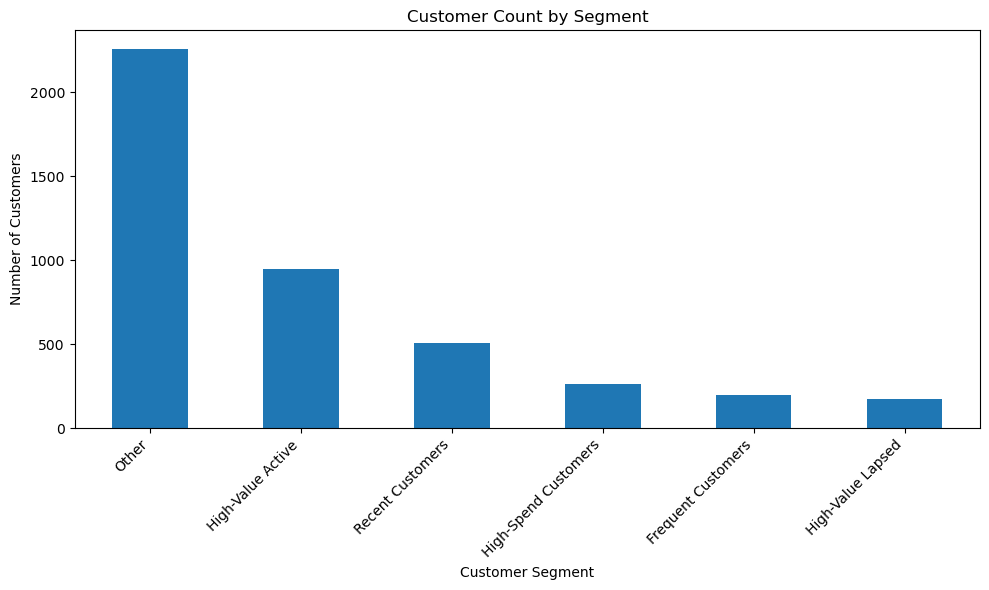

In [44]:
segment_counts = rfm['Segment'].value_counts()

print(segment_counts)

plt.figure(figsize=(10, 6))
segment_counts.plot(kind='bar')

plt.title('Customer Count by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [69]:
segment_revenue = (
    rfm.groupby('Segment')['Monetary']
    .sum()
    .sort_values(ascending=False)
)

print(segment_revenue)

Segment
High-Value Active       5676823.41
Other                   1791668.65
High-Spend Customers     558896.33
High-Value Lapsed        425205.54
Recent Customers         198423.23
Frequent Customers       116900.49
Name: Monetary, dtype: float64


In [68]:
segment_avg_revenue = (
    rfm.groupby('Segment')['Monetary']
    .mean()
    .sort_values(ascending=False)
)

print(segment_avg_revenue)

Segment
High-Value Active       6007.220540
High-Value Lapsed       2457.835491
High-Spend Customers    2149.601269
Other                    794.179366
Frequent Customers       596.431071
Recent Customers         392.140771
Name: Monetary, dtype: float64


In [48]:
print(rfm.columns.tolist())

['CustomerID', 'Recency', 'Frequency', 'Monetary', 'R_Score', 'F_Score', 'M_Score', 'RFM_Score', 'Segment']


In [49]:
print(rfm.head())

  CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0      12346      325          1  77183.60        1        1        5   
1      12347        1          7   4310.00        5        5        5   
2      12348       74          4   1437.24        2        4        4   
3      12349       18          1   1457.55        4        1        4   
4      12350      309          1    294.40        1        1        2   

   RFM_Score               Segment  
0          7  High-Spend Customers  
1         15     High-Value Active  
2         10     High-Value Lapsed  
3          9                 Other  
4          4                 Other  


Segment
Other                   2256
High-Value Active        945
Recent Customers         506
High-Spend Customers     260
Frequent Customers       196
High-Value Lapsed        173
Name: count, dtype: int64


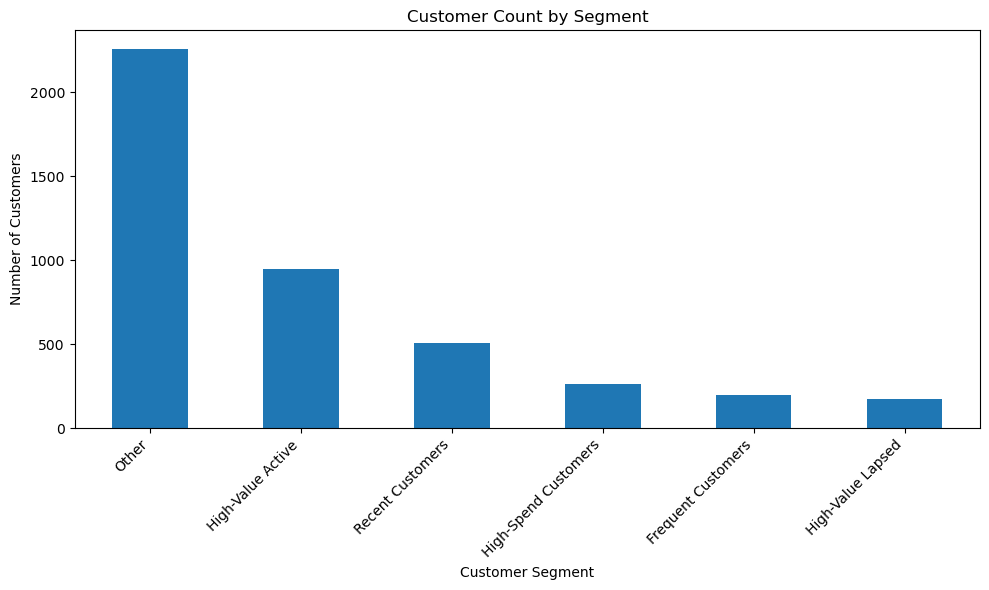

In [50]:
segment_counts = rfm['Segment'].value_counts()

print(segment_counts)

plt.figure(figsize=(10, 6))
segment_counts.plot(kind='bar')

plt.title('Customer Count by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Segment
High-Value Active       5676823.41
Other                   1791668.65
High-Spend Customers     558896.33
High-Value Lapsed        425205.54
Recent Customers         198423.23
Frequent Customers       116900.49
Name: Monetary, dtype: float64


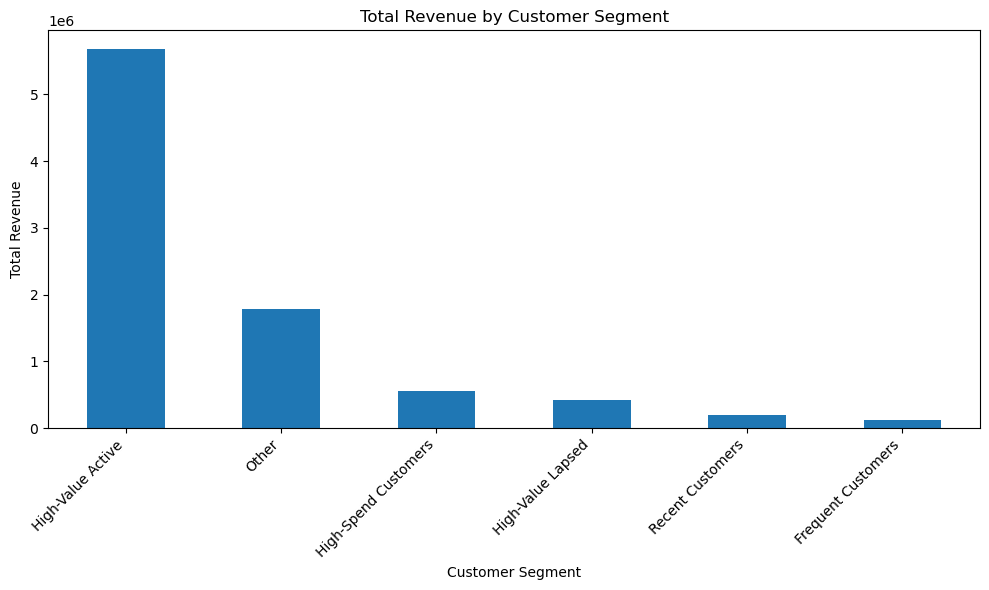

In [51]:
segment_revenue = (
    rfm.groupby('Segment')['Monetary']
    .sum()
    .sort_values(ascending=False)
)

print(segment_revenue)

plt.figure(figsize=(10, 6))
segment_revenue.plot(kind='bar')

plt.title('Total Revenue by Customer Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Total Revenue')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

Segment
High-Value Active       6007.220540
High-Value Lapsed       2457.835491
High-Spend Customers    2149.601269
Other                    794.179366
Frequent Customers       596.431071
Recent Customers         392.140771
Name: Monetary, dtype: float64


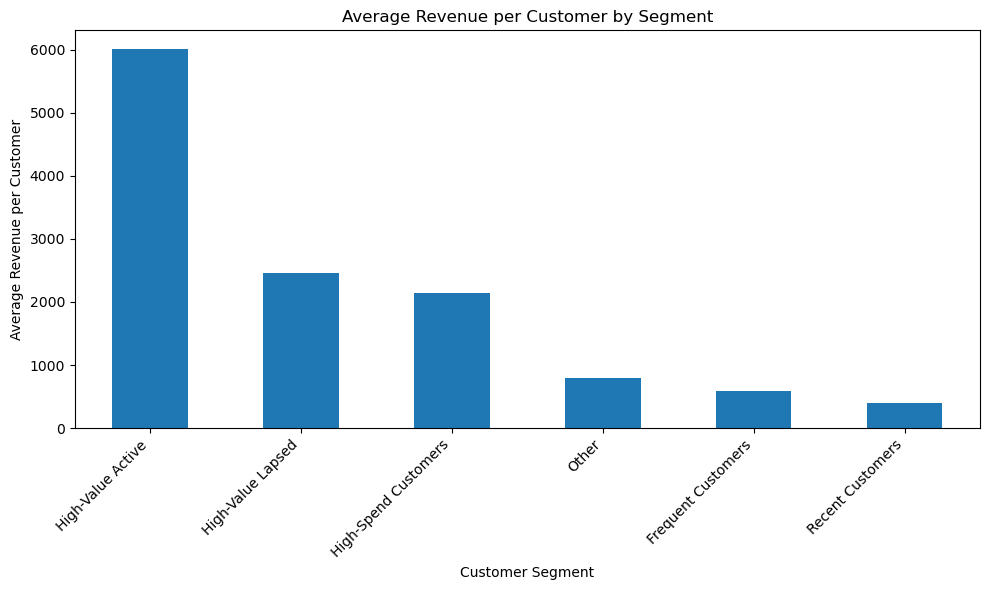

In [52]:
segment_avg_revenue = (
    rfm.groupby('Segment')['Monetary']
    .mean()
    .sort_values(ascending=False)
)

print(segment_avg_revenue)

plt.figure(figsize=(10, 6))
segment_avg_revenue.plot(kind='bar')

plt.title('Average Revenue per Customer by Segment')
plt.xlabel('Customer Segment')
plt.ylabel('Average Revenue per Customer')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

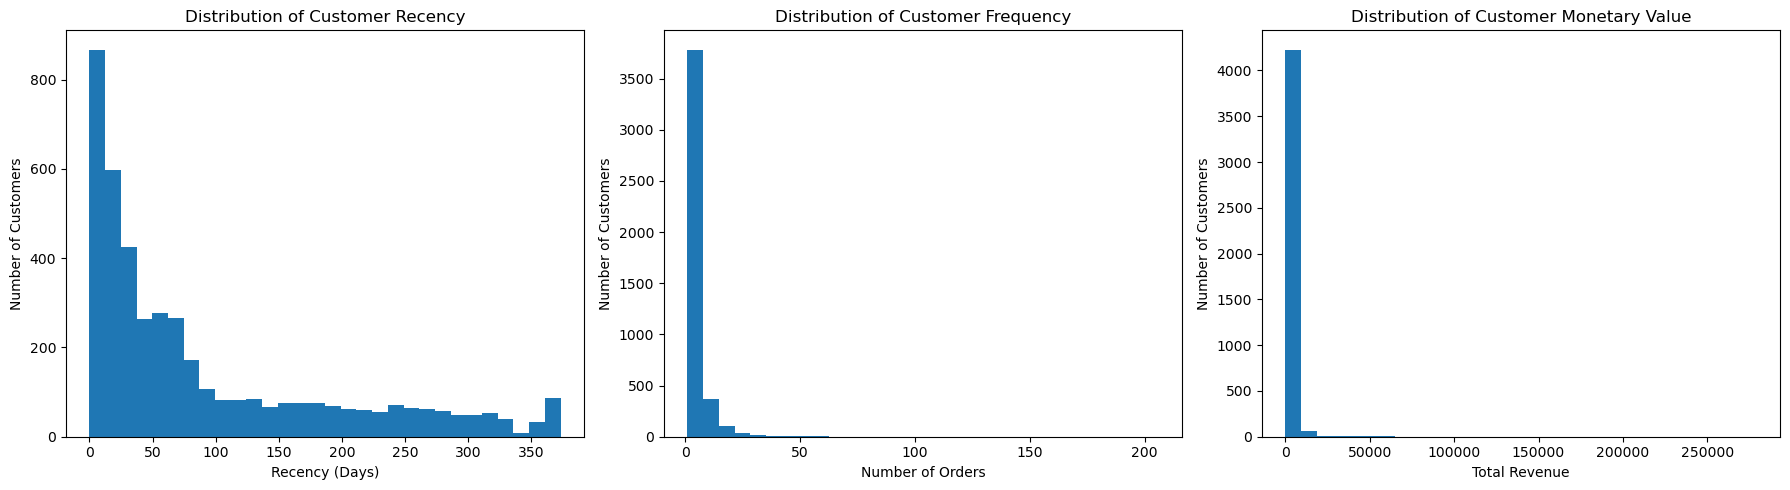

In [53]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Recency
axes[0].hist(rfm['Recency'], bins=30)
axes[0].set_title('Distribution of Customer Recency')
axes[0].set_xlabel('Recency (Days)')
axes[0].set_ylabel('Number of Customers')

# Frequency
axes[1].hist(rfm['Frequency'], bins=30)
axes[1].set_title('Distribution of Customer Frequency')
axes[1].set_xlabel('Number of Orders')
axes[1].set_ylabel('Number of Customers')

# Monetary
axes[2].hist(rfm['Monetary'], bins=30)
axes[2].set_title('Distribution of Customer Monetary Value')
axes[2].set_xlabel('Total Revenue')
axes[2].set_ylabel('Number of Customers')

plt.tight_layout()
plt.show()

            Recency  Frequency  Monetary
Recency    1.000000  -0.260905 -0.121030
Frequency -0.260905   1.000000  0.551241
Monetary  -0.121030   0.551241  1.000000


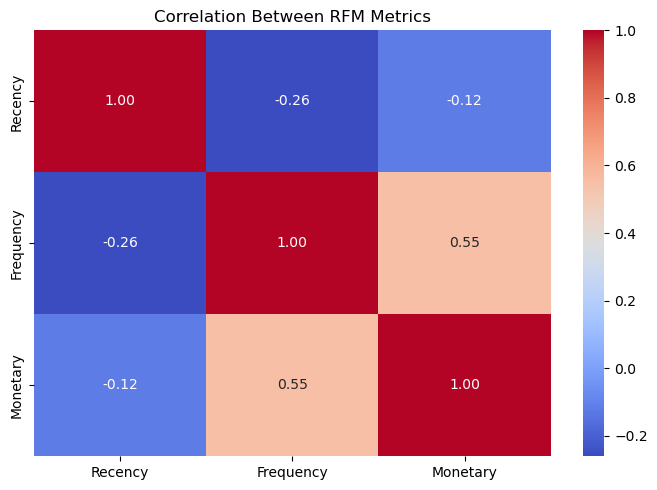

In [54]:
rfm_corr = rfm[['Recency', 'Frequency', 'Monetary']].corr()

print(rfm_corr)

plt.figure(figsize=(7, 5))
sns.heatmap(
    rfm_corr,
    annot=True,
    fmt='.2f',
    cmap='coolwarm'
)

plt.title('Correlation Between RFM Metrics')
plt.tight_layout()
plt.show()

In [55]:
print(df[['CustomerID', 'Country']].head())
print(df['Country'].nunique())
print(df['Country'].unique())

  CustomerID         Country
0      17850  United Kingdom
1      17850  United Kingdom
2      17850  United Kingdom
3      17850  United Kingdom
4      17850  United Kingdom
38
['United Kingdom' 'France' 'Australia' 'Netherlands' 'Germany' 'Norway'
 'EIRE' 'Switzerland' 'Spain' 'Poland' 'Portugal' 'Italy' 'Belgium'
 'Lithuania' 'Japan' 'Iceland' 'Channel Islands' 'Denmark' 'Cyprus'
 'Sweden' 'Finland' 'Austria' 'Bahrain' 'Israel' 'Greece' 'Hong Kong'
 'Singapore' 'Lebanon' 'United Arab Emirates' 'Saudi Arabia'
 'Czech Republic' 'Canada' 'Unspecified' 'Brazil' 'USA'
 'European Community' 'Malta' 'RSA']


In [62]:
customer_country_check = (
    df[df['CustomerID'] != 'Unknown']
    .groupby('CustomerID')['Country']
    .nunique()
)

print("Customers linked to multiple countries:",
      (customer_country_check > 1).sum())

Customers linked to multiple countries: 8


In [63]:
print(
    customer_country_check[customer_country_check > 1]
    .sort_values(ascending=False)
    .head(10)
)

CustomerID
12370    2
12394    2
12417    2
12422    2
12429    2
12431    2
12455    2
12457    2
Name: Country, dtype: int64


In [64]:
customer_country = (
    df[df['CustomerID'] != 'Unknown']
    .groupby(['CustomerID', 'Country'])
    .size()
    .reset_index(name='Transaction_Count')
)

primary_country = (
    customer_country
    .sort_values(['CustomerID', 'Transaction_Count'], ascending=[True, False])
    .drop_duplicates('CustomerID')
    [['CustomerID', 'Country']]
)

print(primary_country.head())
print("Customers with assigned country:", len(primary_country))

  CustomerID         Country
0      12346  United Kingdom
1      12347         Iceland
2      12348         Finland
3      12349           Italy
4      12350          Norway
Customers with assigned country: 4336


In [65]:
rfm_geo = rfm.merge(
    primary_country,
    on='CustomerID',
    how='left'
)

print(rfm_geo.head())
print(rfm_geo['Country'].isna().sum())

  CustomerID  Recency  Frequency  Monetary  R_Score  F_Score  M_Score  \
0      12346      325          1  77183.60        1        1        5   
1      12347        1          7   4310.00        5        5        5   
2      12348       74          4   1437.24        2        4        4   
3      12349       18          1   1457.55        4        1        4   
4      12350      309          1    294.40        1        1        2   

   RFM_Score               Segment         Country  
0          7  High-Spend Customers  United Kingdom  
1         15     High-Value Active         Iceland  
2         10     High-Value Lapsed         Finland  
3          9                 Other           Italy  
4          4                 Other          Norway  
0


In [66]:
country_customers = (
    rfm_geo.groupby('Country')['CustomerID']
    .nunique()
    .sort_values(ascending=False)
)

print(country_customers)

Country
United Kingdom          3918
Germany                   94
France                    87
Spain                     29
Belgium                   24
Switzerland               20
Portugal                  19
Italy                     14
Finland                   12
Norway                    10
Netherlands                9
Austria                    9
Australia                  9
Channel Islands            9
Sweden                     8
Denmark                    8
Japan                      8
Poland                     6
Cyprus                     6
USA                        4
Canada                     4
Unspecified                4
Greece                     4
EIRE                       3
Israel                     3
Malta                      2
United Arab Emirates       2
Bahrain                    2
Czech Republic             1
Lithuania                  1
Lebanon                    1
RSA                        1
Saudi Arabia               1
Singapore                  1
Icelan

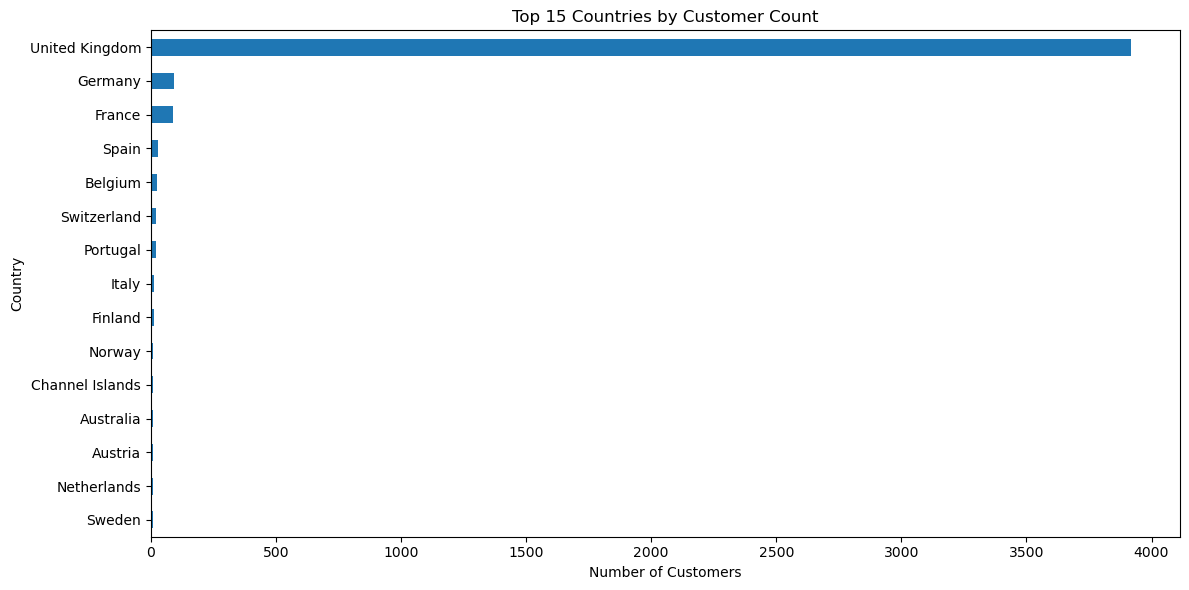

In [67]:
plt.figure(figsize=(12, 6))

country_customers.head(15).sort_values().plot(kind='barh')

plt.title('Top 15 Countries by Customer Count')
plt.xlabel('Number of Customers')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [70]:
country_revenue = (
    rfm_geo.groupby('Country')['Monetary']
    .sum()
    .sort_values(ascending=False)
)

print(country_revenue)

Country
United Kingdom          7267502.23
Netherlands              283889.34
EIRE                     262171.56
Germany                  205569.89
France                   184077.68
Australia                139336.45
Spain                     57056.71
Switzerland               52537.29
Japan                     37416.37
Belgium                   37141.26
Sweden                    36839.33
Norway                    32454.64
Portugal                  26707.95
Channel Islands           20157.44
Finland                   18344.88
Denmark                   17863.92
Italy                     15820.24
Cyprus                    11335.29
Singapore                  9120.39
Austria                    8203.50
Israel                     7221.69
Poland                     6974.65
Greece                     4425.52
Iceland                    4310.00
USA                        3580.39
Canada                     3115.44
Unspecified                2667.07
Malta                      2070.59
United Arab 

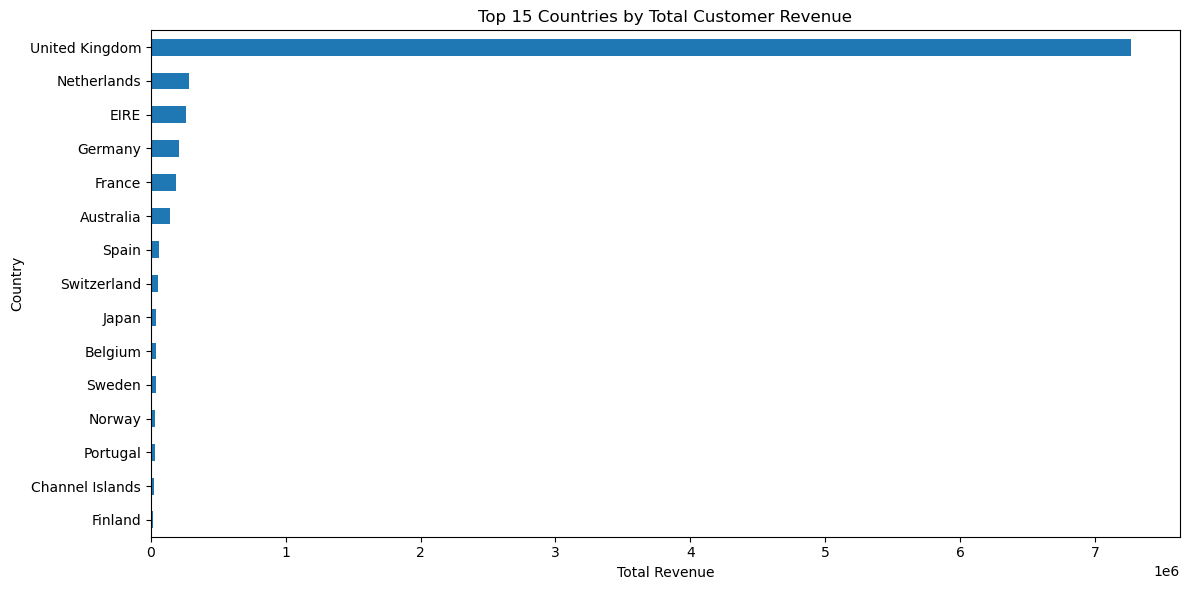

In [71]:
plt.figure(figsize=(12, 6))

country_revenue.head(15).sort_values().plot(kind='barh')

plt.title('Top 15 Countries by Total Customer Revenue')
plt.xlabel('Total Revenue')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [73]:
country_avg_revenue = (
    rfm_geo.groupby('Country')['Monetary']
    .mean()
    .sort_values(ascending=False)
)

print(country_avg_revenue)

Country
EIRE                    87390.520000
Netherlands             31543.260000
Australia               15481.827778
Singapore                9120.390000
Japan                    4677.046250
Sweden                   4604.916250
Iceland                  4310.000000
Norway                   3245.464000
Switzerland              2626.864500
Israel                   2407.230000
Channel Islands          2239.715556
Denmark                  2232.990000
Germany                  2186.913723
France                   2115.835402
Spain                    1967.472759
Cyprus                   1889.215000
United Kingdom           1854.901029
Lebanon                  1693.880000
Lithuania                1661.060000
Belgium                  1547.552500
Finland                  1528.740000
Portugal                 1405.681579
Poland                   1162.441667
European Community       1159.250000
Brazil                   1143.600000
Italy                    1130.017143
Greece                   1106.

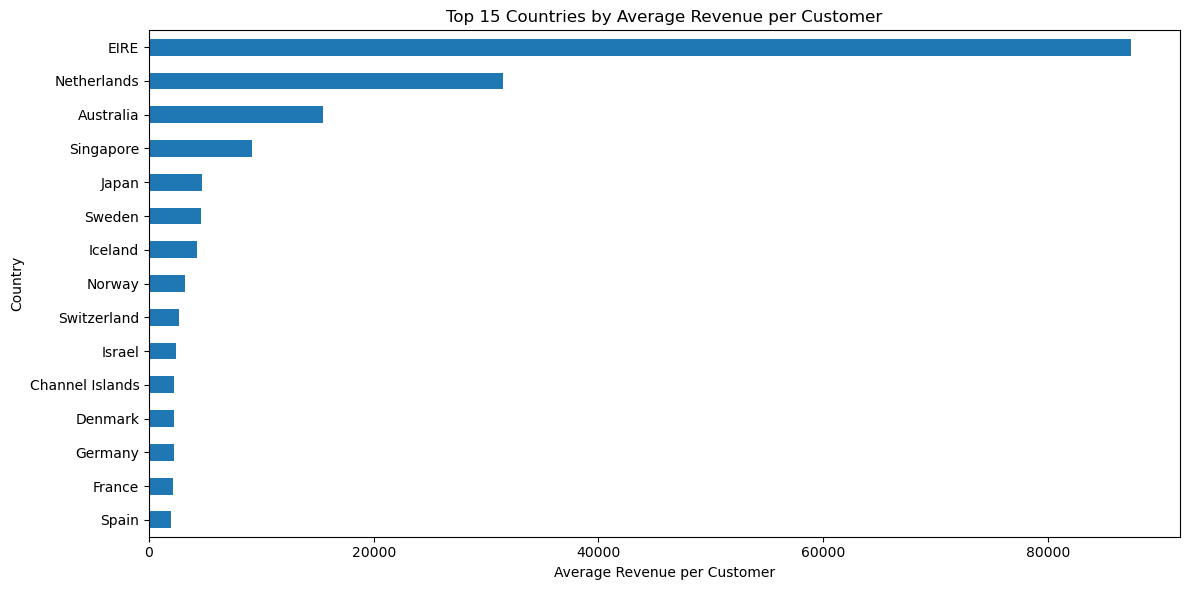

In [74]:
plt.figure(figsize=(12, 6))

country_avg_revenue.head(15).sort_values().plot(kind='barh')

plt.title('Top 15 Countries by Average Revenue per Customer')
plt.xlabel('Average Revenue per Customer')
plt.ylabel('Country')
plt.tight_layout()
plt.show()

In [75]:
country_segment = pd.crosstab(
    rfm_geo['Country'],
    rfm_geo['Segment']
)

print(country_segment.head(15))

Segment             Frequent Customers  High-Spend Customers  \
Country                                                        
Australia                            1                     1   
Austria                              0                     2   
Bahrain                              0                     0   
Belgium                              0                     3   
Brazil                               0                     1   
Canada                               0                     1   
Channel Islands                      0                     6   
Cyprus                               0                     0   
Czech Republic                       0                     0   
Denmark                              0                     3   
EIRE                                 0                     0   
European Community                   0                     1   
Finland                              0                     1   
France                               1  

In [76]:
top_countries = country_customers.head(10).index

country_segment_top10 = (
    country_segment
    .loc[top_countries]
)

print(country_segment_top10)

Segment         Frequent Customers  High-Spend Customers  High-Value Active  \
Country                                                                       
United Kingdom                 192                   199                853   
Germany                          2                    12                 27   
France                           1                     2                 25   
Spain                            0                     4                  5   
Belgium                          0                     3                  9   
Switzerland                      0                     8                  1   
Portugal                         0                     1                  4   
Italy                            0                     2                  2   
Finland                          0                     1                  3   
Norway                           0                     1                  2   

Segment         High-Value Lapsed  Other  Recent Cu

<Figure size 1400x700 with 0 Axes>

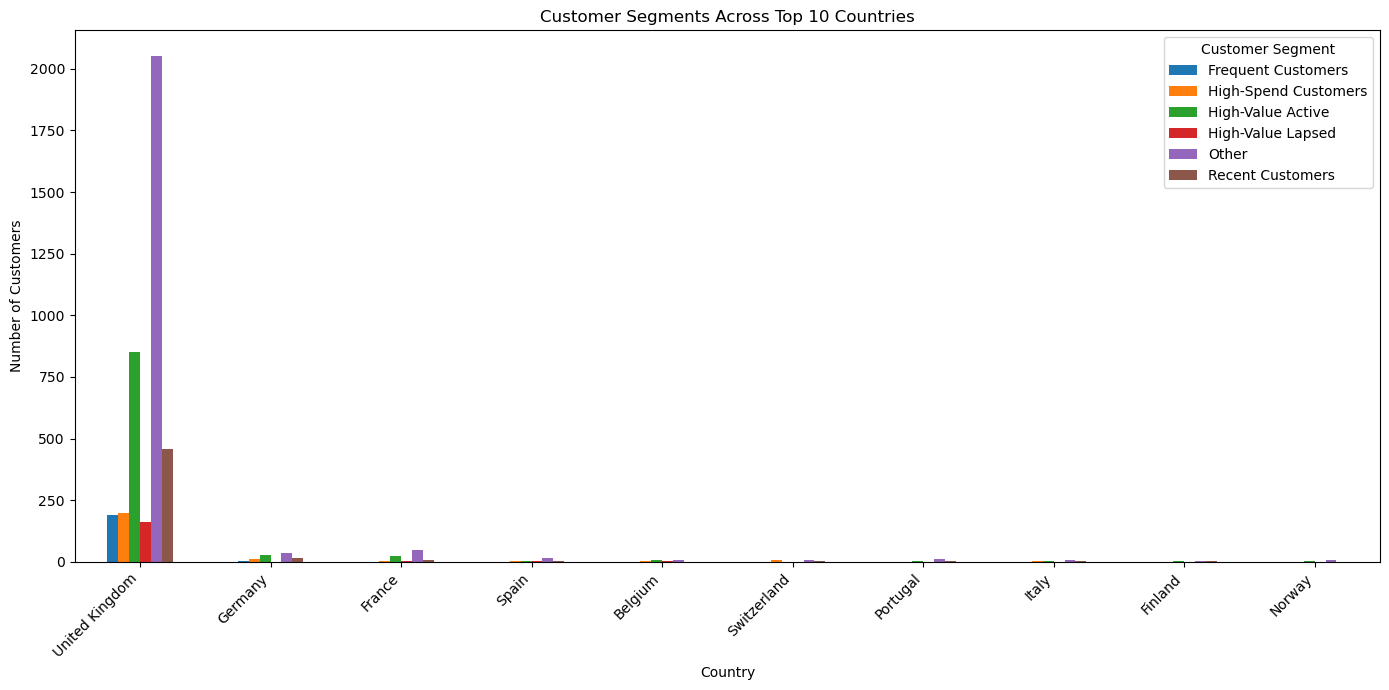

In [77]:
plt.figure(figsize=(14, 7))

country_segment_top10.plot(
    kind='bar',
    figsize=(14, 7)
)

plt.title('Customer Segments Across Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Number of Customers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Customer Segment')

plt.tight_layout()
plt.show()

In [78]:
country_segment_pct = (
    country_segment
    .div(country_segment.sum(axis=1), axis=0)
    * 100
)

country_segment_pct_top10 = country_segment_pct.loc[top_countries]

print(country_segment_pct_top10.round(2))

Segment         Frequent Customers  High-Spend Customers  High-Value Active  \
Country                                                                       
United Kingdom                4.90                  5.08              21.77   
Germany                       2.13                 12.77              28.72   
France                        1.15                  2.30              28.74   
Spain                         0.00                 13.79              17.24   
Belgium                       0.00                 12.50              37.50   
Switzerland                   0.00                 40.00               5.00   
Portugal                      0.00                  5.26              21.05   
Italy                         0.00                 14.29              14.29   
Finland                       0.00                  8.33              25.00   
Norway                        0.00                 10.00              20.00   

Segment         High-Value Lapsed  Other  Recent Cu

<Figure size 1400x700 with 0 Axes>

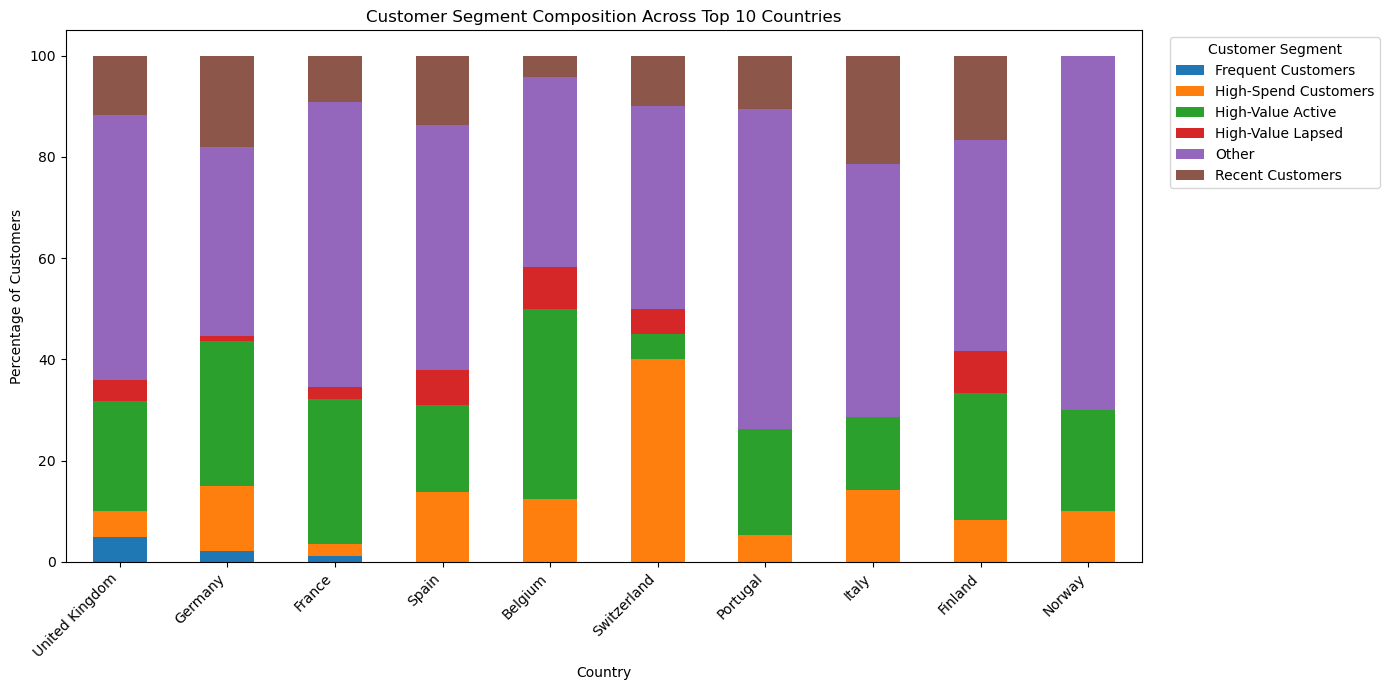

In [79]:
plt.figure(figsize=(14, 7))

country_segment_pct_top10.plot(
    kind='bar',
    stacked=True,
    figsize=(14, 7)
)

plt.title('Customer Segment Composition Across Top 10 Countries')
plt.xlabel('Country')
plt.ylabel('Percentage of Customers')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Customer Segment', bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

In [80]:
segment_summary = (
    rfm.groupby('Segment')
    .agg(
        Customers=('CustomerID', 'nunique'),
        Total_Revenue=('Monetary', 'sum'),
        Avg_Revenue=('Monetary', 'mean'),
        Avg_Recency=('Recency', 'mean'),
        Avg_Frequency=('Frequency', 'mean')
    )
)

segment_summary['Revenue_Share_%'] = (
    segment_summary['Total_Revenue']
    / segment_summary['Total_Revenue'].sum()
    * 100
)

segment_summary = segment_summary.sort_values(
    'Total_Revenue',
    ascending=False
)

print(segment_summary.round(2))

                      Customers  Total_Revenue  Avg_Revenue  Avg_Recency  \
Segment                                                                    
High-Value Active           945     5676823.41      6007.22        11.50   
Other                      2256     1791668.65       794.18       134.55   
High-Spend Customers        260      558896.33      2149.60       125.24   
High-Value Lapsed           173      425205.54      2457.84       123.68   
Recent Customers            506      198423.23       392.14        16.23   
Frequent Customers          196      116900.49       596.43       107.04   

                      Avg_Frequency  Revenue_Share_%  
Segment                                               
High-Value Active             11.10            64.75  
Other                          2.16            20.43  
High-Spend Customers           2.03             6.37  
High-Value Lapsed              5.46             4.85  
Recent Customers               1.65             2.26  
Freque

In [81]:
country_segment_revenue = (
    rfm_geo.groupby(['Country', 'Segment'])
    .agg(
        Customers=('CustomerID', 'nunique'),
        Total_Revenue=('Monetary', 'sum'),
        Avg_Revenue=('Monetary', 'mean')
    )
    .reset_index()
)

country_segment_revenue = country_segment_revenue.sort_values(
    'Total_Revenue',
    ascending=False
)

print(country_segment_revenue.head(20).round(2))

            Country               Segment  Customers  Total_Revenue  \
98   United Kingdom     High-Value Active        853     4569998.10   
100  United Kingdom                 Other       2053     1583381.60   
97   United Kingdom  High-Spend Customers        199      422798.89   
99   United Kingdom     High-Value Lapsed        162      399766.93   
64      Netherlands     High-Value Active          2      280419.06   
26             EIRE     High-Value Active          2      257830.35   
101  United Kingdom      Recent Customers        459      176957.17   
42          Germany     High-Value Active         27      142769.47   
2         Australia     High-Value Active          2      127345.19   
36           France     High-Value Active         25      119154.09   
96   United Kingdom    Frequent Customers        192      114599.54   
38           France                 Other         49       51708.07   
83           Sweden     High-Value Active          3       34784.19   
79    

In [82]:
rfm['Monetary']

0       77183.60
1        4310.00
2        1437.24
3        1457.55
4         294.40
          ...   
4331      180.60
4332       80.82
4333      178.05
4334     2088.93
4335     1837.28
Name: Monetary, Length: 4336, dtype: float64

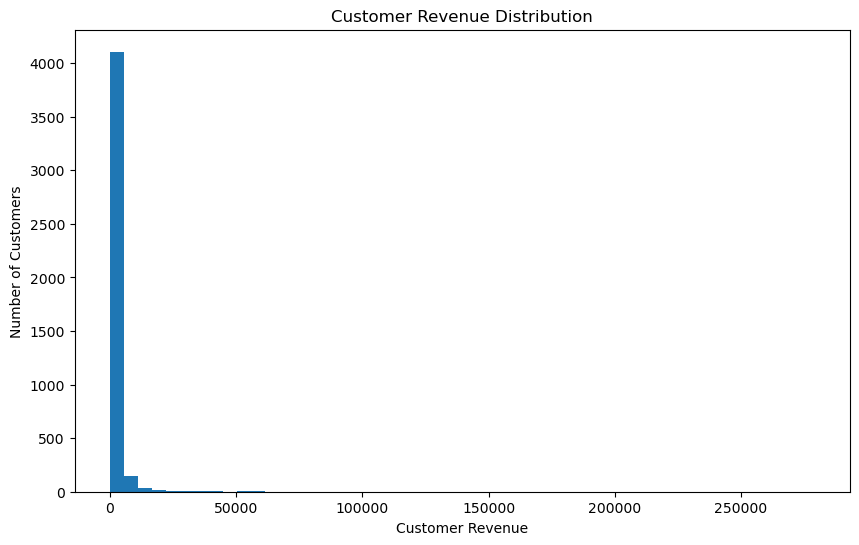

In [83]:
plt.figure(figsize=(10,6))

plt.hist(rfm['Monetary'], bins=50)

plt.xlabel('Customer Revenue')
plt.ylabel('Number of Customers')
plt.title('Customer Revenue Distribution')

plt.show()

In [84]:
segment_revenue = rfm.groupby('Segment')['Monetary'].sum().sort_values(ascending=False)